# 실습 3: 대상 감성 분석 & PII 감지
**소요시간: 30분** | 난이도: ⭐⭐⭐

## 학습 목표
1. `detect_targeted_sentiment`로 개체별 세밀한 감성을 분석합니다.
2. `detect_pii_entities`로 개인식별정보(PII)를 자동 감지합니다.
3. PII를 마스킹 처리하는 함수를 구현합니다.

## API 개요
```python
# 대상 감성 분석 (개체별 감성)
comprehend.detect_targeted_sentiment(Text='...', LanguageCode='en')

# PII 감지
comprehend.detect_pii_entities(Text='...', LanguageCode='en')
```

### Targeted Sentiment 결과 구조
```
{
  'Text': 'battery life',
  'Type': 'ATTRIBUTE',
  'Mentions': [{
    'Text': 'battery life',
    'MentionSentiment': {'Sentiment': 'POSITIVE', 'SentimentScore': {...}}
  }]
}
```

> ⚠️ detect_targeted_sentiment 및 detect_pii_entities는 **영어(en)**만 지원합니다.


---
## 🏢 기업 시나리오 — 금융 콜센터 품질·정보보호팀

당신은 금융사 콜센터의 **상담 품질·개인정보보호 담당자**입니다.
매일 **수천 건의 상담 기록**이 텍스트로 쌓입니다.

이번 실습에서는 Comprehend로 다음을 자동화합니다.
1. **대상 감성 분석(Targeted Sentiment)** → 고객이 '카드·앱·상담원' 중 무엇에 만족/불만인지 항목별 파악
2. **PII 감지·마스킹** → 상담 기록 속 이름·카드번호·연락처 등 개인정보를 자동 탐지·가림 처리

> ⚠️ 대상 감성·PII 감지는 **영어(en)만 지원**하므로 이번 실습 데이터는 영어이며, 리전은 **us-east-1**을 사용합니다.
> 💡 실무에서는 분석팀에 상담 로그를 넘기기 전에 PII를 자동 마스킹해 **개인정보보호법·규정 준수**를 보장합니다.


In [1]:
# ✅ [제공 코드] 환경 초기화
import boto3
import matplotlib.pyplot as plt
import pandas as pd
import re

# 한글 폰트 설정 (SageMaker Studio) — 최초 1회만 설치, 이후 즉시 로드
try:
    import koreanize_matplotlib
except ImportError:
    import sys, subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'koreanize-matplotlib'])
    import koreanize_matplotlib

# ⚠️ 대상 감성(targeted_sentiment)·PII 감지는 영어(en)만 지원 → us-east-1 사용
comprehend = boto3.client('comprehend', region_name='us-east-1')
print('✅ Comprehend 클라이언트 생성 완료 (us-east-1)')


✅ Comprehend 클라이언트 생성 완료 (us-east-1)


## ✏️ TODO 1: detect_targeted_sentiment — 개체별 감성 분석

제품 리뷰에서 각 개체(배터리, 카메라, 디자인 등)별 감성을 개별 분석하세요.


In [2]:
# ✏️ TODO 1: detect_targeted_sentiment API를 호출하고 개체별 감성을 출력하세요
review = (
    "The camera quality is absolutely stunning and takes great photos. "
    "However, the battery life is terrible and drains too fast. "
    "The design looks premium but the screen has some issues."
)

response = comprehend.detect_targeted_sentiment(
    Text=review,           # ← review
    LanguageCode='en'    # ← 'en'
)

entities = response['Entities']  # ← 'Entities'
print(f'분석된 개체: {len(entities)}개')
print('-' * 60)
for e in entities:
    mention = e['Mentions'][0]
    text     = mention['Text']                                # ← 'Text'
    sent     = mention['MentionSentiment']['Sentiment']            # ← 'Sentiment'
    score    = mention['MentionSentiment']['SentimentScore']
    dominant = max(score, key=score.get)
    print(f"  {text:<20} → {sent:<12} (최고: {dominant} {score[dominant]:.3f})")


분석된 개체: 6개
------------------------------------------------------------
  camera               → POSITIVE     (최고: Positive 1.000)
  quality              → POSITIVE     (최고: Positive 1.000)
  battery              → NEGATIVE     (최고: Negative 1.000)
  design               → POSITIVE     (최고: Positive 1.000)
  screen               → NEGATIVE     (최고: Negative 1.000)
  some                 → NEUTRAL      (최고: Neutral 1.000)


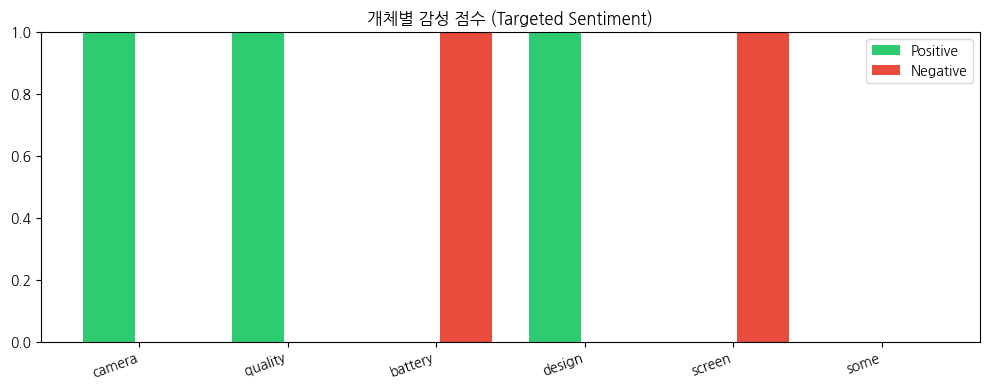

In [3]:
# ✅ [제공 코드] 개체별 감성 비교 시각화
rows = []
for e in entities:
    m    = e['Mentions'][0]
    sc   = m['MentionSentiment']['SentimentScore']
    rows.append({'entity': m['Text'], 'sentiment': m['MentionSentiment']['Sentiment'],
                 'pos': sc['Positive'], 'neg': sc['Negative']})
df = pd.DataFrame(rows).drop_duplicates('entity')

fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(df))
ax.bar([i-0.2 for i in x], df['pos'], 0.35, label='Positive', color='#2ecc71')
ax.bar([i+0.2 for i in x], df['neg'], 0.35, label='Negative', color='#e74c3c')
ax.set_xticks(list(x))
ax.set_xticklabels(df['entity'], rotation=20, ha='right')
ax.set_title('개체별 감성 점수 (Targeted Sentiment)')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()


## ✏️ TODO 2: detect_pii_entities — PII 감지

텍스트에서 개인식별정보(이름, 이메일, 전화번호, 주소 등)를 감지하세요.


In [4]:
# ✏️ TODO 2: detect_pii_entities API를 호출하고 결과를 출력하세요
pii_text = (
    "Hello, my name is John Smith. You can reach me at john.smith@email.com "
    "or call me at 555-123-4567. My address is 123 Main Street, New York, NY 10001. "
    "My credit card number is 4532-1234-5678-9012."
)

response = comprehend.detect_pii_entities(
    Text=pii_text,           # ← pii_text
    LanguageCode='en'    # ← 'en'
)

pii_entities = response['Entities']  # ← 'Entities'
print(f'감지된 PII: {len(pii_entities)}개')
print('-' * 60)
for p_ent in pii_entities:
    start = p_ent['BeginOffset']   # ← 'BeginOffset'
    end   = p_ent['EndOffset']   # ← 'EndOffset'
    text  = pii_text[start:end]
    print(f"  [{p_ent['Type']:<20}] {text:<30} (신뢰도: {p_ent['Score']:.3f})")


감지된 PII: 5개
------------------------------------------------------------
  [NAME                ] John Smith                     (신뢰도: 1.000)
  [EMAIL               ] john.smith@email.com           (신뢰도: 1.000)
  [PHONE               ] 555-123-4567                   (신뢰도: 0.994)
  [ADDRESS             ] 123 Main Street, New York, NY 10001 (신뢰도: 0.999)
  [CREDIT_DEBIT_NUMBER ] 4532-1234-5678-9012            (신뢰도: 1.000)


## ✏️ TODO 3: PII 마스킹 함수 구현

감지된 PII를 `***` 로 치환하는 마스킹 함수를 완성하세요.


In [5]:
# ✏️ TODO 3: PII를 마스킹하는 함수를 완성하세요
def mask_pii(text, pii_entities):
    """PII 위치를 뒤에서부터 치환하여 offset 오염 방지"""
    sorted_entities = sorted(pii_entities,
                              key=lambda x: x['BeginOffset'],  # ← 'BeginOffset'
                              reverse=True)           # ← True  (뒤에서부터)
    masked = text
    for ent in sorted_entities:
        start  = ent['BeginOffset']  # ← 'BeginOffset'
        end    = ent['EndOffset']  # ← 'EndOffset'
        marker = f"[{ent['Type']}]"
        masked = masked[:start] + marker + masked[end:]
    return masked

masked_text = mask_pii(pii_text, pii_entities)
print('원본:')
print(' ', pii_text)
print('\n마스킹 결과:')
print(' ', masked_text)


원본:
  Hello, my name is John Smith. You can reach me at john.smith@email.com or call me at 555-123-4567. My address is 123 Main Street, New York, NY 10001. My credit card number is 4532-1234-5678-9012.

마스킹 결과:
  Hello, my name is [NAME]. You can reach me at [EMAIL] or call me at [PHONE]. My address is [ADDRESS]. My credit card number is [CREDIT_DEBIT_NUMBER].


---
## 🔗 실무로 연결하기

`상담 로그(텍스트)` → `PII 자동 마스킹` → `(안전한) 분석용 데이터` → `품질·만족도 분석`

- 항목별 감성을 집계하면 **'어떤 기능에 불만이 집중되는지'** 가 보입니다 → 제품 개선 우선순위
- PII 마스킹 자동화로 **사람이 직접 가릴 필요가 없어** 휴먼 에러와 규정 위반 위험을 제거합니다.


## 💡 심화 도전
1. 동일 제품 리뷰에서 detect_sentiment(전체)와 detect_targeted_sentiment(개체별)의 결과를 비교해보세요.
2. 고객 상담 로그에서 PII를 마스킹하는 배치 처리 파이프라인을 설계해보세요.
3. PII 유형별 빈도를 집계하여 어떤 PII가 가장 많이 노출되는지 분석해보세요.


## ✅ 정답 코드

👆 모두 풀고 난 후 확인하세요

```python
# TODO 1
response = comprehend.detect_targeted_sentiment(Text=review, LanguageCode='en')
entities = response['Entities']
text  = mention['Text']
sent  = mention['MentionSentiment']['Sentiment']

# TODO 2
response = comprehend.detect_pii_entities(Text=pii_text, LanguageCode='en')
pii_entities = response['Entities']
start = p_ent['BeginOffset']
end   = p_ent['EndOffset']

# TODO 3
sorted_entities = sorted(pii_entities, key=lambda x: x['BeginOffset'], reverse=True)
start  = ent['BeginOffset']
end    = ent['EndOffset']
```
